In [8]:
import os
import sys
from pathlib import Path

from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from omegaconf import OmegaConf

import quest.utils.utils as qutils

# -----------------------------
# IMPORTANT: set your QueST repo path
# -----------------------------
QUEST_REPO = "/NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST"
CONFIG_DIR = os.path.join(QUEST_REPO, "config")
AUTOENCODER_ROOT = os.path.join(
    QUEST_REPO,
    "experiments/real_robot/REAL_ROBOT_MULTI",
)

if QUEST_REPO not in sys.path:
    sys.path.append(QUEST_REPO)

OmegaConf.register_new_resolver("eval", eval, replace=True)

device = "cuda:5"
data_prefix = "/NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/demos"


def _infer_extra_overrides(algo_name, exp_name, variant_name):
    extra = []
    if algo_name == "quest_ft_adaln":
        mode = variant_name.removeprefix("block_32_ds_4_ft_")
        if mode not in {"max", "avg", "avg_max", "conv"}:
            raise ValueError(f"Cannot infer ft_downsample_mode from variant_name={variant_name}")
        extra.append(f"algo.ft_downsample_mode={mode}")

        if exp_name.endswith("_100hz"):
            extra.append("algo.dataset.ft_config.ft_source=force_history")
        elif exp_name.endswith("_10hz"):
            extra.append("algo.dataset.ft_config.ft_source=state")
    return extra


def _cfg_from_stage0_dir(stage0_dir):
    stage0_dir = Path(stage0_dir)
    seed = stage0_dir.parent.name
    variant_name = stage0_dir.parent.parent.name
    exp_name = stage0_dir.parent.parent.parent.name
    algo_name = stage0_dir.parent.parent.parent.parent.name

    overrides = [
        "task=real_robot_state",
        f"algo={algo_name}",
        f"exp_name={exp_name}",
        f"variant_name={variant_name}",
        "training.use_tqdm=false",
        "training.save_all_checkpoints=true",
        "training.use_amp=false",
        "train_dataloader.persistent_workers=true",
        "train_dataloader.num_workers=6",
        "train_dataloader.multiprocessing_context=fork",
        "make_unique_experiment_dir=false",
        "algo.skill_block_size=32",
        "algo.downsample_factor=4",
        f"seed={seed}",
        f"data_prefix={data_prefix}",
        f"device={device}",
    ]
    overrides.extend(_infer_extra_overrides(algo_name, exp_name, variant_name))

    with initialize_config_dir(config_dir=CONFIG_DIR, version_base=None):
        cfg = compose(config_name="train_autoencoder.yaml", overrides=overrides)

    # Keep compatibility with older checkpoints/notebooks that expected this explicit FSQ level.
    cfg["algo"]["policy"]["autoencoder"]["fsq_level"] = [8, 5, 5, 5]
    return cfg, algo_name, exp_name, variant_name, seed


def load_autoencoder_from_stage0(stage0_dir):
    cfg, algo_name, exp_name, variant_name, seed = _cfg_from_stage0_dir(stage0_dir)
    model = instantiate(cfg.algo.policy, shape_meta=cfg.task.shape_meta)
    model = model.to(device)
    model.eval()

    checkpoint_path = qutils.get_latest_checkpoint(str(stage0_dir))
    state_dict = qutils.load_state(checkpoint_path)
    qutils.soft_load_state_dict(model, state_dict["model"])
    model.eval()
    model.autoencoder.eval()

    rel_stage0_dir = os.path.relpath(stage0_dir, QUEST_REPO)
    key = f"{algo_name}/{exp_name}/{variant_name}/{seed}"
    return key, {
        "model": model,
        "autoencoder": model.autoencoder,
        "cfg": cfg,
        "checkpoint_path": checkpoint_path,
        "stage0_dir": str(stage0_dir),
        "relative_stage0_dir": rel_stage0_dir,
        "algo_name": algo_name,
        "exp_name": exp_name,
        "variant_name": variant_name,
        "seed": seed,
    }


stage0_dirs = sorted(Path(AUTOENCODER_ROOT).glob("*/*/*/*/stage_0"))
if not stage0_dirs:
    raise FileNotFoundError(f"No stage_0 autoencoder directories found under {AUTOENCODER_ROOT}")

autoencoder_models = {}
for stage0_dir in stage0_dirs:
    key, item = load_autoencoder_from_stage0(stage0_dir)
    autoencoder_models[key] = item
    print(f"[{len(autoencoder_models):02d}] {key}")
    print(f"     checkpoint: {item['checkpoint_path']}")
    print(f"     autoencoder: {type(item['autoencoder']).__name__}")

# Backward-compatible aliases for existing visualization cells.
def set_active_autoencoder(key=None):
    global active_key, active_item, model, autoencoder, cfg
    if key is None:
        key = next(iter(autoencoder_models))
    active_key = key
    active_item = autoencoder_models[key]
    model = active_item["model"]
    autoencoder = active_item["autoencoder"]
    cfg = active_item["cfg"]
    print(f"Active autoencoder: {active_key}")
    return active_item

set_active_autoencoder()
print(f"Loaded {len(autoencoder_models)} autoencoders.")
print("Available keys:")
for key in autoencoder_models:
    print(" -", key)


[01] quest/lowdim_autoencoder_quest/block_32_ds_4_quest/0
     checkpoint: /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/experiments/real_robot/REAL_ROBOT_MULTI/quest/lowdim_autoencoder_quest/block_32_ds_4_quest/0/stage_0/multitask_model_epoch_0200.pth
     autoencoder: SkillVAE
[02] quest_ft_adaln/lowdim_autoencoder_avg_10hz/block_32_ds_4_ft_avg/0
     checkpoint: /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/experiments/real_robot/REAL_ROBOT_MULTI/quest_ft_adaln/lowdim_autoencoder_avg_10hz/block_32_ds_4_ft_avg/0/stage_0/multitask_model_epoch_0200.pth
     autoencoder: SkillVAEFTAdaLN
[03] quest_ft_adaln/lowdim_autoencoder_avg_max_10hz/block_32_ds_4_ft_avg_max/0
     checkpoint: /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/experiments/real_robot/REAL_ROBOT_MULTI/quest_ft_adaln/lowdim_autoencoder_avg_max_10hz/block_32_ds_4_ft_avg_max/0/stage_0/multitask_model_epoch_0200.pth
     autoencoder: SkillVAEFTAdaLN
[04] quest_ft_adaln/lowdim_autoencoder_con

In [9]:
import random
import pickle
from collections import defaultdict
from typing import Dict, Optional
import numpy as np
import torch

RIGHT_ACTION_SLICE = slice(7, 14)   # 7 dims
RIGHT_FORCE_SLICE  = slice(20, 23)  # 3 dims
RIGHT_TORQUE_SLICE = slice(29, 32)  # 3 dims
DOWNSAMPLE_FACTOR = 4

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_right_actions_from_episode(ep):
    acts = np.asarray(ep["actions"], dtype=np.float32)   # (T, 14)
    return acts[:, RIGHT_ACTION_SLICE]                   # (T, 7)

def to_action_tensor(action_np, device):
    """
    action_np: (T, 7)
    return: (1, T, 7)
    """
    return torch.tensor(action_np, dtype=torch.float32, device=device).unsqueeze(0)

def trim_zero_action_episode(ep: Dict, trailing_keep: int = 5) -> Optional[Dict]:
    if "actions" not in ep or len(ep["actions"]) == 0:
        return None

    actions = [np.asarray(a) for a in ep["actions"]]
    T = len(actions)

    # 앞쪽 zero 제거
    start_idx = 0
    while start_idx < T and np.all(actions[start_idx] == 0):
        start_idx += 1

    if start_idx == T:
        return None

    # 뒤쪽 zero 제거
    end_idx = T - 1
    while end_idx >= 0 and np.all(actions[end_idx] == 0):
        end_idx -= 1

    trim_end = min(T, end_idx + 1 + trailing_keep)

    return {k: v[start_idx:trim_end] for k, v in ep.items()}

def _extract_state_from_obs(obs):
    candidate_keys = [
        "state",
        "robot_state",
        "proprio",
        "lowdim",
        "low_dim_state",
        "states",
    ]

    for k in candidate_keys:
        if k in obs:
            arr = np.asarray(obs[k], dtype=np.float32)
            if arr.ndim == 2 and arr.shape[0] == 1:
                arr = arr[0]
            return arr

    raise KeyError(f"State key not found. Available keys: {list(obs.keys())}")


def get_force_torque_magnitude_from_episode(ep):
    """
    return:
        ft_mag: (T,)
        ft_mag[t] = sqrt(||force[t]||^2 + ||torque[t]||^2)
    """
    mags = []

    for obs in ep["observations"]:
        state = _extract_state_from_obs(obs)

        force = state[RIGHT_FORCE_SLICE]
        torque = state[RIGHT_TORQUE_SLICE]

        mag = np.sqrt(np.sum(force ** 2) + np.sum(torque ** 2))
        mags.append(mag)

    return np.asarray(mags, dtype=np.float32)


def get_skill_force_torque_magnitude(ep, valid_T, downsample_factor=DOWNSAMPLE_FACTOR):
    """
    skill token별 force+torque magnitude 평균
    return:
        skill_ft_mag: (H,)
    """
    ft_mag = get_force_torque_magnitude_from_episode(ep)
    ft_mag = ft_mag[:valid_T]

    H = valid_T // downsample_factor
    skill_ft_mag = []

    for h in range(H):
        s = h * downsample_factor
        e = (h + 1) * downsample_factor
        skill_ft_mag.append(float(np.mean(ft_mag[s:e])))

    return np.asarray(skill_ft_mag, dtype=np.float32)

def load_episodes_from_pkl(pkl_path: str):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    episodes = []
    cur = defaultdict(list)
    keys = list(data[0].keys())

    for step in data:
        for k in keys:
            cur[k].append(step.get(k))

        if step.get("dones", False):
            episodes.append({k: cur[k] for k in keys})
            cur = defaultdict(list)

    return episodes

@torch.no_grad()
def extract_skill_codes_and_indices(model, action_np, device):
    """
    action_np: (T, 7)

    returns:
        codes_np   : (H, D)
        indices_np : (H,)
        z_np       : (H, D)  # quantize 전 continuous latent
    """
    x = to_action_tensor(action_np, device)             # (1, T, 7)

    z = model.autoencoder.encode(x)                     # (1, H, D)
    codes, indices, pp, pp_sample, aux_loss = model.autoencoder.quantize(z)

    if torch.is_tensor(z):
        z = z.detach().cpu().numpy()
    if torch.is_tensor(codes):
        codes = codes.detach().cpu().numpy()
    if torch.is_tensor(indices):
        indices = indices.detach().cpu().numpy()

    z = np.asarray(z)
    codes = np.asarray(codes)
    indices = np.asarray(indices)

    if z.ndim == 3 and z.shape[0] == 1:
        z = z[0]
    if codes.ndim == 3 and codes.shape[0] == 1:
        codes = codes[0]
    if indices.ndim == 2 and indices.shape[0] == 1:
        indices = indices[0]

    return codes, indices, z

In [10]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def get_force_torque_mag_from_episode(ep):
    """
    return:
        force_mag:  (T,)
        torque_mag: (T,)
    """
    force_mags = []
    torque_mags = []

    for obs in ep["observations"]:
        state = _extract_state_from_obs(obs)

        force = state[RIGHT_FORCE_SLICE]
        torque = state[RIGHT_TORQUE_SLICE]

        force_mags.append(float(np.linalg.norm(force)))
        torque_mags.append(float(np.linalg.norm(torque)))

    return (
        np.asarray(force_mags, dtype=np.float32),
        np.asarray(torque_mags, dtype=np.float32),
    )


def get_skill_force_torque_mag_separate(
    ep,
    valid_T,
    downsample_factor=DOWNSAMPLE_FACTOR,
):
    """
    각 skill token에 대응하는 4-step force/torque magnitude 평균
    return:
        skill_force_mag:  (H,)
        skill_torque_mag: (H,)
    """
    force_mag, torque_mag = get_force_torque_mag_from_episode(ep)

    force_mag = force_mag[:valid_T]
    torque_mag = torque_mag[:valid_T]

    H = valid_T // downsample_factor

    skill_force_mag = []
    skill_torque_mag = []

    for h in range(H):
        s = h * downsample_factor
        e = (h + 1) * downsample_factor

        skill_force_mag.append(float(np.mean(force_mag[s:e])))
        skill_torque_mag.append(float(np.mean(torque_mag[s:e])))

    return (
        np.asarray(skill_force_mag, dtype=np.float32),
        np.asarray(skill_torque_mag, dtype=np.float32),
    )


def count_unique_skills_by_percentile_bins(skill_indices, values, num_bins=10):
    """
    values 기준 percentile bin별 unique skill index 수 계산
    """
    skill_indices = np.asarray(skill_indices)
    values = np.asarray(values, dtype=np.float32)

    assert len(skill_indices) == len(values)

    percentiles = np.linspace(0, 100, num_bins + 1)
    edges = np.percentile(values, percentiles)

    unique_counts = []
    bin_labels = []

    for i in range(num_bins):
        lo = edges[i]
        hi = edges[i + 1]

        if i == num_bins - 1:
            mask = (values >= lo) & (values <= hi)
        else:
            mask = (values >= lo) & (values < hi)

        unique_count = len(set(skill_indices[mask].tolist()))
        unique_counts.append(unique_count)

        bin_labels.append(f"{i*10}-{(i+1)*10}%")

    return unique_counts, bin_labels, edges

def count_unique_skills_by_value_bins(skill_indices, values, num_bins=10):
    skill_indices = np.asarray(skill_indices)
    values = np.asarray(values, dtype=np.float32)

    edges = np.linspace(values.min(), values.max(), num_bins + 1)

    unique_counts = []
    token_ratios = []
    bin_labels = []

    total_tokens = len(values)

    for i in range(num_bins):
        lo = edges[i]
        hi = edges[i + 1]

        if i == num_bins - 1:
            mask = (values >= lo) & (values <= hi)
        else:
            mask = (values >= lo) & (values < hi)

        unique_counts.append(len(set(skill_indices[mask].tolist())))
        token_ratios.append(float(np.sum(mask)) / total_tokens * 100.0)
        bin_labels.append(f"{lo:.2f}-{hi:.2f}")

    return unique_counts, token_ratios, bin_labels, edges

def plot_unique_skill_hist_force_torque_for_task(
    model,
    task_path: str,
    device: str,
    num_bins: int = 10,
):
    """
    task_path 아래의 모든 pkl을 읽고,
    force percentile bin / torque percentile bin별 unique skill index 수를 histogram으로 그림.

    Example:
        plot_unique_skill_hist_force_torque_for_task(
            model=model,
            task_path="/home/seunghyo/real_robot/demos/multi_usb",
            device=device,
        )
    """

    pkl_paths = sorted(
        [
            p for p in glob.glob(os.path.join(task_path, "**", "*.pkl"), recursive=True)
            if "demos" in os.path.basename(p)
        ]
    )

    print(f"Found pkl files: {len(pkl_paths)}")

    all_skill_indices = []
    all_skill_force_mag = []
    all_skill_torque_mag = []

    total_eps = 0
    valid_eps = 0

    for pkl_path in pkl_paths:
        episodes = load_episodes_from_pkl(pkl_path)
        total_eps += len(episodes)

        for ep in episodes:
            trimmed = trim_zero_action_episode(ep)
            if trimmed is None:
                continue

            action_np = get_right_actions_from_episode(trimmed)
            T = len(action_np)

            valid_T = (T // DOWNSAMPLE_FACTOR) * DOWNSAMPLE_FACTOR
            if valid_T < DOWNSAMPLE_FACTOR:
                continue

            action_np = action_np[:valid_T]

            _, indices, _ = extract_skill_codes_and_indices(
                model,
                action_np,
                device,
            )

            force_mag, torque_mag = get_skill_force_torque_mag_separate(
                trimmed,
                valid_T=valid_T,
                downsample_factor=DOWNSAMPLE_FACTOR,
            )

            H = min(len(indices), len(force_mag), len(torque_mag))

            all_skill_indices.append(np.asarray(indices[:H]))
            all_skill_force_mag.append(force_mag[:H])
            all_skill_torque_mag.append(torque_mag[:H])

            valid_eps += 1

    if len(all_skill_indices) == 0:
        print("No valid skill data found.")
        return

    all_skill_indices = np.concatenate(all_skill_indices, axis=0)
    all_skill_force_mag = np.concatenate(all_skill_force_mag, axis=0)
    all_skill_torque_mag = np.concatenate(all_skill_torque_mag, axis=0)

    print(f"Total episodes: {total_eps}")
    print(f"Valid episodes: {valid_eps}")
    print(f"Total skill tokens: {len(all_skill_indices)}")
    print(f"Total unique skills: {len(set(all_skill_indices.tolist()))}")

    # force_counts, bin_labels, force_edges = count_unique_skills_by_percentile_bins(
    #     all_skill_indices,
    #     all_skill_force_mag,
    #     num_bins=num_bins,
    # )

    # torque_counts, _, torque_edges = count_unique_skills_by_percentile_bins(
    #     all_skill_indices,
    #     all_skill_torque_mag,
    #     num_bins=num_bins,
    # )

    force_counts, force_token_ratios, force_bin_labels, force_edges = (
        count_unique_skills_by_value_bins(
            all_skill_indices,
            all_skill_force_mag,
            num_bins=num_bins,
        )
    )

    torque_counts, torque_token_ratios, torque_bin_labels, torque_edges = (
        count_unique_skills_by_value_bins(
            all_skill_indices,
            all_skill_torque_mag,
            num_bins=num_bins,
        )
    )

    # bin별 token 비율 계산
    def token_ratio_by_edges(values, edges, num_bins=10):
        values = np.asarray(values, dtype=np.float32)
        total = len(values)
        ratios = []

        for i in range(num_bins):
            lo = edges[i]
            hi = edges[i + 1]

            if i == num_bins - 1:
                mask = (values >= lo) & (values <= hi)
            else:
                mask = (values >= lo) & (values < hi)

            ratios.append(float(np.sum(mask)) / total * 100.0)

        return ratios

    # force_token_ratios = token_ratio_by_edges(
    #     all_skill_force_mag,
    #     force_edges,
    #     num_bins=num_bins,
    # )

    # torque_token_ratios = token_ratio_by_edges(
    #     all_skill_torque_mag,
    #     torque_edges,
    #     num_bins=num_bins,
    # )

    task_name = Path(task_path).name

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

    # x = np.arange(len(bin_labels))
    x = np.arange(len(force_bin_labels))
    width = 0.4

    # -----------------------------
    # Force subplot
    # -----------------------------
    ax1 = axes[0]
    ax2 = ax1.twinx()

    ax1.bar(
        x - width / 2,
        force_counts,
        width=width,
        label="Unique skill count",
    )
    ax2.bar(
        x + width / 2,
        force_token_ratios,
        width=width,
        alpha=0.45,
        label="Step ratio (%)",
    )

    ax1.set_title(f"{task_name} - Force Magnitude Percentile")
    ax1.set_ylabel("Unique skill count")
    ax2.set_ylabel("Step ratio (%)")
    ax1.grid(axis="y", alpha=0.3)
    ax1.set_xticks(x)
    ax1.set_xticklabels(force_bin_labels)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    # -----------------------------
    # Torque subplot
    # -----------------------------
    ax1 = axes[1]
    ax2 = ax1.twinx()

    ax1.bar(
        x - width / 2,
        torque_counts,
        width=width,
        label="Unique skill count",
    )
    ax2.bar(
        x + width / 2,
        torque_token_ratios,
        width=width,
        alpha=0.45,
        label="Step ratio (%)",
    )

    ax1.set_title(f"{task_name} - Torque Magnitude Percentile")
    ax1.set_ylabel("Unique skill count")
    ax2.set_ylabel("Step ratio (%)")
    ax1.set_xlabel("Magnitude value bin")
    ax1.set_xticks(x)
    # ax1.set_xticklabels(bin_labels, rotation=45)
    ax1.set_xticklabels(torque_bin_labels)
    ax1.grid(axis="y", alpha=0.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# Updated binning/plotting helpers.
# bin_mode="value" uses equal-width force/torque magnitude bins.
# bin_mode="percentile" uses equal-percentile bins.
# -----------------------------------------------------------------------------

def count_unique_skills_by_bins(skill_indices, values, num_bins=10, bin_mode="value"):
    skill_indices = np.asarray(skill_indices)
    values = np.asarray(values, dtype=np.float32)

    assert len(skill_indices) == len(values)
    if len(values) == 0:
        raise ValueError("values is empty")

    if bin_mode == "value":
        edges = np.linspace(values.min(), values.max(), num_bins + 1)
        bin_labels = [f"{edges[i]:.2f}-{edges[i + 1]:.2f}" for i in range(num_bins)]
        x_label = "Magnitude value bin"
    elif bin_mode == "percentile":
        percentiles = np.linspace(0, 100, num_bins + 1)
        edges = np.percentile(values, percentiles)
        bin_labels = [f"{int(percentiles[i])}-{int(percentiles[i + 1])}%" for i in range(num_bins)]
        x_label = "Magnitude percentile bin"
    else:
        raise ValueError(f"Unsupported bin_mode={bin_mode}. Expected 'value' or 'percentile'.")

    unique_counts = []
    token_ratios = []
    total_tokens = len(values)

    for i in range(num_bins):
        lo = edges[i]
        hi = edges[i + 1]

        if i == num_bins - 1:
            mask = (values >= lo) & (values <= hi)
        else:
            mask = (values >= lo) & (values < hi)

        unique_counts.append(len(set(skill_indices[mask].tolist())))
        token_ratios.append(float(np.sum(mask)) / total_tokens * 100.0)

    return unique_counts, token_ratios, bin_labels, edges, x_label


def plot_unique_skill_hist_force_torque_for_task(
    model,
    task_path: str,
    device: str,
    num_bins: int = 10,
    bin_mode: str = "value",
    model_label: str | None = None,
    output_dir: str | os.PathLike | None = None,
):
    """
    Plot unique skill counts by force/torque magnitude bins for one task.

    Args:
        bin_mode: "value" for equal-width magnitude bins, or "percentile" for percentile bins.
        output_dir: If provided, saves the figure as a PNG in this directory.
    """
    pkl_paths = sorted(
        [
            p for p in glob.glob(os.path.join(task_path, "**", "*.pkl"), recursive=True)
            if "demos" in os.path.basename(p)
        ]
    )

    print(f"Found pkl files: {len(pkl_paths)}")

    all_skill_indices = []
    all_skill_force_mag = []
    all_skill_torque_mag = []

    total_eps = 0
    valid_eps = 0

    for pkl_path in pkl_paths:
        episodes = load_episodes_from_pkl(pkl_path)
        total_eps += len(episodes)

        for ep in episodes:
            trimmed = trim_zero_action_episode(ep)
            if trimmed is None:
                continue

            action_np = get_right_actions_from_episode(trimmed)
            T = len(action_np)

            valid_T = (T // DOWNSAMPLE_FACTOR) * DOWNSAMPLE_FACTOR
            if valid_T < DOWNSAMPLE_FACTOR:
                continue

            action_np = action_np[:valid_T]

            _, indices, _ = extract_skill_codes_and_indices(
                model,
                action_np,
                device,
            )

            force_mag, torque_mag = get_skill_force_torque_mag_separate(
                trimmed,
                valid_T=valid_T,
                downsample_factor=DOWNSAMPLE_FACTOR,
            )

            H = min(len(indices), len(force_mag), len(torque_mag))

            all_skill_indices.append(np.asarray(indices[:H]))
            all_skill_force_mag.append(force_mag[:H])
            all_skill_torque_mag.append(torque_mag[:H])

            valid_eps += 1

    if len(all_skill_indices) == 0:
        print("No valid skill data found.")
        return None

    all_skill_indices = np.concatenate(all_skill_indices, axis=0)
    all_skill_force_mag = np.concatenate(all_skill_force_mag, axis=0)
    all_skill_torque_mag = np.concatenate(all_skill_torque_mag, axis=0)

    print(f"Total episodes: {total_eps}")
    print(f"Valid episodes: {valid_eps}")
    print(f"Total skill tokens: {len(all_skill_indices)}")
    print(f"Total unique skills: {len(set(all_skill_indices.tolist()))}")

    force_counts, force_token_ratios, force_bin_labels, force_edges, x_label = (
        count_unique_skills_by_bins(
            all_skill_indices,
            all_skill_force_mag,
            num_bins=num_bins,
            bin_mode=bin_mode,
        )
    )

    torque_counts, torque_token_ratios, torque_bin_labels, torque_edges, _ = (
        count_unique_skills_by_bins(
            all_skill_indices,
            all_skill_torque_mag,
            num_bins=num_bins,
            bin_mode=bin_mode,
        )
    )

    task_name = Path(task_path).name
    title_prefix = task_name if model_label is None else f"{task_name} | {model_label}"

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
    width = 0.4

    # -----------------------------
    # Force subplot
    # -----------------------------
    x = np.arange(len(force_bin_labels))
    ax1 = axes[0]
    ax2 = ax1.twinx()

    ax1.bar(
        x - width / 2,
        force_counts,
        width=width,
        label="Unique skill count",
    )
    ax2.bar(
        x + width / 2,
        force_token_ratios,
        width=width,
        alpha=0.45,
        label="Token ratio (%)",
    )

    ax1.set_title(f"{title_prefix} - Force Magnitude ({bin_mode})")
    ax1.set_ylabel("Unique skill count")
    ax2.set_ylabel("Token ratio (%)")
    ax1.grid(axis="y", alpha=0.3)
    ax1.set_xticks(x)
    ax1.set_xticklabels(force_bin_labels, rotation=45 if bin_mode == "value" else 0, ha="right" if bin_mode == "value" else "center")
    ax1.set_xlabel(x_label)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    # -----------------------------
    # Torque subplot
    # -----------------------------
    x = np.arange(len(torque_bin_labels))
    ax1 = axes[1]
    ax2 = ax1.twinx()

    ax1.bar(
        x - width / 2,
        torque_counts,
        width=width,
        label="Unique skill count",
    )
    ax2.bar(
        x + width / 2,
        torque_token_ratios,
        width=width,
        alpha=0.45,
        label="Token ratio (%)",
    )

    ax1.set_title(f"{title_prefix} - Torque Magnitude ({bin_mode})")
    ax1.set_ylabel("Unique skill count")
    ax2.set_ylabel("Token ratio (%)")
    ax1.set_xlabel(x_label)
    ax1.set_xticks(x)
    ax1.set_xticklabels(torque_bin_labels, rotation=45 if bin_mode == "value" else 0, ha="right" if bin_mode == "value" else "center")
    ax1.grid(axis="y", alpha=0.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    plt.tight_layout()

    save_path = None
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        safe_task = re.sub(r"[^A-Za-z0-9_.-]+", "_", task_name).strip("_")
        safe_label = re.sub(r"[^A-Za-z0-9_.-]+", "_", model_label or "model").strip("_")
        save_path = output_dir / f"{safe_task}__{safe_label}__{bin_mode}_{num_bins}bins.png"
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved figure: {save_path}")

    plt.show()

    return {
        "skill_indices": all_skill_indices,
        "force_mag": all_skill_force_mag,
        "torque_mag": all_skill_torque_mag,
        "force_counts": force_counts,
        "force_token_ratios": force_token_ratios,
        "force_bin_labels": force_bin_labels,
        "force_edges": force_edges,
        "torque_counts": torque_counts,
        "torque_token_ratios": torque_token_ratios,
        "torque_bin_labels": torque_bin_labels,
        "torque_edges": torque_edges,
        "bin_mode": bin_mode,
        "num_bins": num_bins,
        "task_path": task_path,
        "model_label": model_label,
        "save_path": str(save_path) if save_path is not None else None,
    }


# -----------------------------------------------------------------------------
# Model comparison plots: one force figure and one torque figure per task/bin mode.
# -----------------------------------------------------------------------------

def collect_skill_force_torque_for_task(
    model,
    task_path: str,
    device: str,
):
    pkl_paths = sorted(
        [
            p for p in glob.glob(os.path.join(task_path, "**", "*.pkl"), recursive=True)
            if "demos" in os.path.basename(p)
        ]
    )

    all_skill_indices = []
    all_skill_force_mag = []
    all_skill_torque_mag = []

    total_eps = 0
    valid_eps = 0

    for pkl_path in pkl_paths:
        episodes = load_episodes_from_pkl(pkl_path)
        total_eps += len(episodes)

        for ep in episodes:
            trimmed = trim_zero_action_episode(ep)
            if trimmed is None:
                continue

            action_np = get_right_actions_from_episode(trimmed)
            T = len(action_np)

            valid_T = (T // DOWNSAMPLE_FACTOR) * DOWNSAMPLE_FACTOR
            if valid_T < DOWNSAMPLE_FACTOR:
                continue

            action_np = action_np[:valid_T]
            _, indices, _ = extract_skill_codes_and_indices(model, action_np, device)

            force_mag, torque_mag = get_skill_force_torque_mag_separate(
                trimmed,
                valid_T=valid_T,
                downsample_factor=DOWNSAMPLE_FACTOR,
            )

            H = min(len(indices), len(force_mag), len(torque_mag))
            all_skill_indices.append(np.asarray(indices[:H]))
            all_skill_force_mag.append(force_mag[:H])
            all_skill_torque_mag.append(torque_mag[:H])
            valid_eps += 1

    if not all_skill_indices:
        return None

    return {
        "skill_indices": np.concatenate(all_skill_indices, axis=0),
        "force_mag": np.concatenate(all_skill_force_mag, axis=0),
        "torque_mag": np.concatenate(all_skill_torque_mag, axis=0),
        "total_eps": total_eps,
        "valid_eps": valid_eps,
    }


def make_magnitude_bin_edges(values, num_bins=10, bin_mode="percentile"):
    values = np.asarray(values, dtype=np.float32)
    if bin_mode == "value":
        edges = np.linspace(values.min(), values.max(), num_bins + 1)
        labels = [f"{edges[i]:.2f}-{edges[i + 1]:.2f}" for i in range(num_bins)]
        x_label = "Magnitude value bin"
    elif bin_mode == "percentile":
        percentiles = np.linspace(0, 100, num_bins + 1)
        edges = np.percentile(values, percentiles)
        labels = [f"{int(percentiles[i])}-{int(percentiles[i + 1])}%" for i in range(num_bins)]
        x_label = "Magnitude percentile bin"
    else:
        raise ValueError(f"Unsupported bin_mode={bin_mode}. Expected 'value' or 'percentile'.")
    return edges, labels, x_label


def count_unique_skills_by_fixed_edges(skill_indices, values, edges):
    skill_indices = np.asarray(skill_indices)
    values = np.asarray(values, dtype=np.float32)
    counts = []
    for i in range(len(edges) - 1):
        lo = edges[i]
        hi = edges[i + 1]
        if i == len(edges) - 2:
            mask = (values >= lo) & (values <= hi)
        else:
            mask = (values >= lo) & (values < hi)
        counts.append(len(set(skill_indices[mask].tolist())))
    return np.asarray(counts, dtype=np.int32)


def short_model_label(model_key):
    parts = model_key.split("/")
    if len(parts) >= 3:
        exp_name = parts[1]
        variant_name = parts[2]
        if exp_name.startswith("lowdim_autoencoder_"):
            exp_name = exp_name.replace("lowdim_autoencoder_", "")
        if variant_name.startswith("block_32_ds_4_"):
            variant_name = variant_name.replace("block_32_ds_4_", "")
        return exp_name if exp_name != "quest" else "quest"
    return model_key


def plot_model_comparison_unique_skill_counts(
    model_stats,
    task_path: str,
    quantity: str,
    num_bins: int = 10,
    bin_mode: str = "percentile",
    output_dir: str | os.PathLike = "output",
    y_max: int | None = None,
):
    if quantity not in {"force", "torque"}:
        raise ValueError("quantity must be 'force' or 'torque'")

    value_key = f"{quantity}_mag"
    first_stats = next(iter(model_stats.values()))
    edges, bin_labels, x_label = make_magnitude_bin_edges(
        first_stats[value_key],
        num_bins=num_bins,
        bin_mode=bin_mode,
    )

    model_keys = list(model_stats.keys())
    counts_by_model = []
    for key in model_keys:
        stats = model_stats[key]
        counts = count_unique_skills_by_fixed_edges(
            stats["skill_indices"],
            stats[value_key],
            edges,
        )
        counts_by_model.append(counts)
    counts_by_model = np.stack(counts_by_model, axis=0)

    if y_max is None:
        y_max = int(np.max(counts_by_model))
    y_max = max(1, int(np.ceil(y_max * 1.10)))

    task_name = Path(task_path).name
    x = np.arange(num_bins)
    n_models = len(model_keys)
    width = min(0.82 / max(n_models, 1), 0.18)

    fig, ax = plt.subplots(figsize=(14, 5.5))
    for model_idx, key in enumerate(model_keys):
        offset = (model_idx - (n_models - 1) / 2.0) * width
        ax.bar(
            x + offset,
            counts_by_model[model_idx],
            width=width,
            label=short_model_label(key),
        )

    ax.set_title(f"{task_name} - Unique Skills by {quantity.capitalize()} Magnitude ({bin_mode})")
    ax.set_ylabel("Unique skill count")
    ax.set_xlabel(x_label)
    ax.set_ylim(0, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(
        bin_labels,
        rotation=45 if bin_mode == "value" else 0,
        ha="right" if bin_mode == "value" else "center",
    )
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, ncols=2)

    plt.tight_layout()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    safe_task = re.sub(r"[^A-Za-z0-9_.-]+", "_", task_name).strip("_")
    save_path = output_dir / f"{safe_task}__{quantity}__{bin_mode}_{num_bins}bins.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure: {save_path}")
    plt.show()

    return {
        "quantity": quantity,
        "counts_by_model": counts_by_model,
        "model_keys": model_keys,
        "bin_labels": bin_labels,
        "edges": edges,
        "save_path": str(save_path),
        "y_max": y_max,
    }


def plot_all_models_force_torque_comparison(
    autoencoder_models,
    task_path: str,
    device: str,
    num_bins: int = 10,
    bin_mode: str = "percentile",
    output_dir: str | os.PathLike = "output",
):
    model_stats = {}
    for key, item in autoencoder_models.items():
        print("\n" + "=" * 100)
        print(f"Collecting: {key}")
        print("=" * 100)
        stats = collect_skill_force_torque_for_task(
            model=item["model"],
            task_path=task_path,
            device=device,
        )
        if stats is None:
            print(f"No valid skill data found for {key}; skipping.")
            continue
        model_stats[key] = stats
        print(
            f"valid_eps={stats['valid_eps']} | tokens={len(stats['skill_indices'])} | "
            f"unique_skills={len(set(stats['skill_indices'].tolist()))}"
        )

    if not model_stats:
        raise ValueError("No valid model stats collected.")

    force_edges, _, _ = make_magnitude_bin_edges(
        next(iter(model_stats.values()))["force_mag"],
        num_bins=num_bins,
        bin_mode=bin_mode,
    )
    torque_edges, _, _ = make_magnitude_bin_edges(
        next(iter(model_stats.values()))["torque_mag"],
        num_bins=num_bins,
        bin_mode=bin_mode,
    )

    global_y_max = 0
    for stats in model_stats.values():
        global_y_max = max(
            global_y_max,
            int(np.max(count_unique_skills_by_fixed_edges(stats["skill_indices"], stats["force_mag"], force_edges))),
            int(np.max(count_unique_skills_by_fixed_edges(stats["skill_indices"], stats["torque_mag"], torque_edges))),
        )

    force_result = plot_model_comparison_unique_skill_counts(
        model_stats,
        task_path=task_path,
        quantity="force",
        num_bins=num_bins,
        bin_mode=bin_mode,
        output_dir=output_dir,
        y_max=global_y_max,
    )
    torque_result = plot_model_comparison_unique_skill_counts(
        model_stats,
        task_path=task_path,
        quantity="torque",
        num_bins=num_bins,
        bin_mode=bin_mode,
        output_dir=output_dir,
        y_max=global_y_max,
    )

    return {
        "model_stats": model_stats,
        "force": force_result,
        "torque": torque_result,
    }



Collecting: quest/lowdim_autoencoder_quest/block_32_ds_4_quest/0
valid_eps=50 | tokens=2290 | unique_skills=211

Collecting: quest_ft_adaln/lowdim_autoencoder_avg_10hz/block_32_ds_4_ft_avg/0
valid_eps=50 | tokens=2290 | unique_skills=259

Collecting: quest_ft_adaln/lowdim_autoencoder_avg_max_10hz/block_32_ds_4_ft_avg_max/0
valid_eps=50 | tokens=2290 | unique_skills=274

Collecting: quest_ft_adaln/lowdim_autoencoder_conv_10hz/block_32_ds_4_ft_conv/0
valid_eps=50 | tokens=2290 | unique_skills=377

Collecting: quest_ft_adaln/lowdim_autoencoder_max_10hz/block_32_ds_4_ft_max/0
valid_eps=50 | tokens=2290 | unique_skills=305
Saved figure: /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/multi_usb/multi_usb__force__value_10bins.png


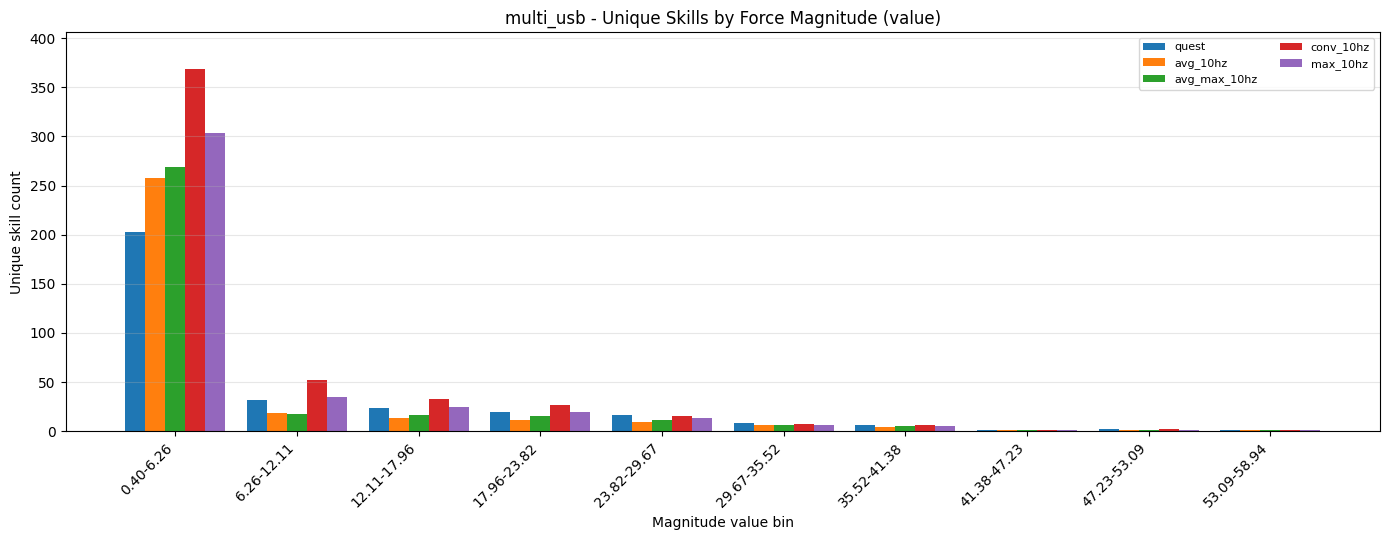

Saved figure: /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/multi_usb/multi_usb__torque__value_10bins.png


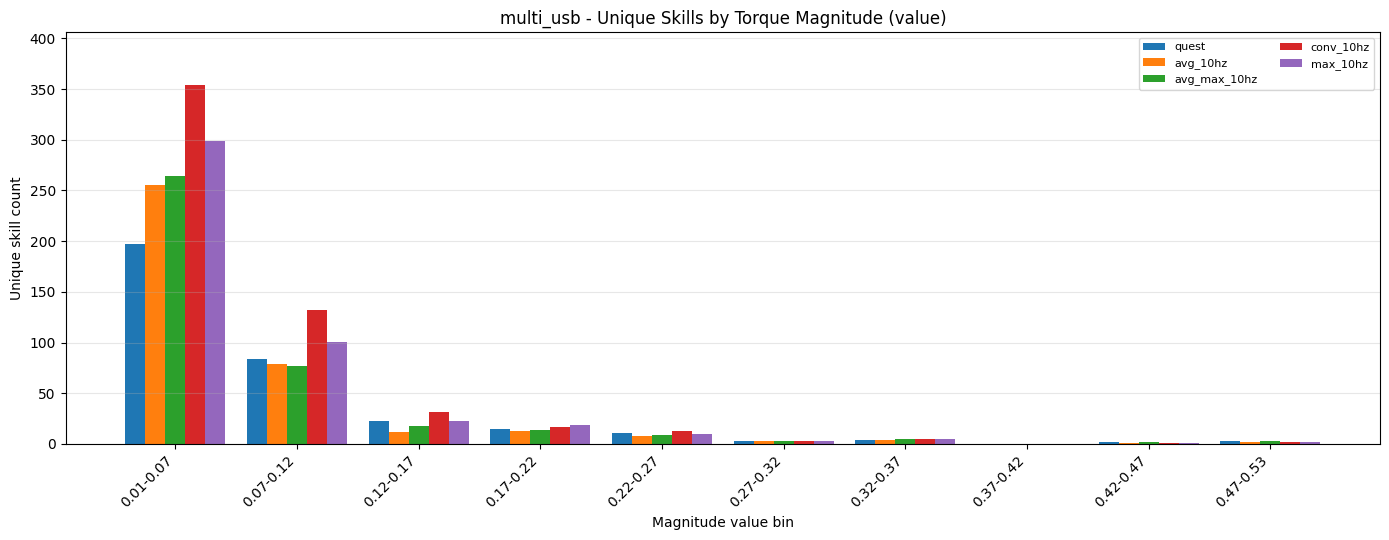

Saved comparison plots:
 - /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/multi_usb/multi_usb__force__value_10bins.png
 - /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/multi_usb/multi_usb__torque__value_10bins.png


In [ ]:
# Compare all loaded autoencoders on one task.
# This saves exactly two figures: one force comparison and one torque comparison.
NUM_BINS = 10

TASKS = "multi_usb"

for task in TASKS:
    for bin_mode in ["value", "percentile"]:
        task_path = os.path.join(data_prefix, task)
        output_dir = Path.cwd() / "output" / task

        comparison_results = plot_all_models_force_torque_comparison(
            autoencoder_models=autoencoder_models,
            task_path=task_path,
            device=device,
            num_bins=NUM_BINS,
            bin_mode=bin_mode,
            output_dir=output_dir,
        )

        print("Saved comparison plots:")
        print(" -", comparison_results["force"]["save_path"])
        print(" -", comparison_results["torque"]["save_path"])


In [11]:
# All-task normalized force/torque comparison helpers.
# These helpers do not modify the per-task plotting code above.
import json

FORCE_TORQUE_STATS_PATH = os.path.join(data_prefix, "force_torque_stats.json")


def load_task_force_torque_stats(stats_path=FORCE_TORQUE_STATS_PATH):
    with open(stats_path, "r") as f:
        raw = json.load(f)

    stats = {}
    for task_name, item in raw.items():
        stats[task_name] = {
            "force_mean": np.asarray(item["force"]["mean"], dtype=np.float32),
            "force_std": np.maximum(np.asarray(item["force"]["std"], dtype=np.float32), 1e-8),
            "torque_mean": np.asarray(item["torque"]["mean"], dtype=np.float32),
            "torque_std": np.maximum(np.asarray(item["torque"]["std"], dtype=np.float32), 1e-8),
        }
    return stats


def get_normalized_force_torque_mag_from_episode(ep, task_stats):
    force_mags = []
    torque_mags = []

    for obs in ep["observations"]:
        state = _extract_state_from_obs(obs)
        force = state[RIGHT_FORCE_SLICE]
        torque = state[RIGHT_TORQUE_SLICE]

        force_norm = (force - task_stats["force_mean"]) / task_stats["force_std"]
        torque_norm = (torque - task_stats["torque_mean"]) / task_stats["torque_std"]

        force_mags.append(float(np.linalg.norm(force_norm)))
        torque_mags.append(float(np.linalg.norm(torque_norm)))

    return (
        np.asarray(force_mags, dtype=np.float32),
        np.asarray(torque_mags, dtype=np.float32),
    )


def get_skill_normalized_force_torque_mag_separate(
    ep,
    task_stats,
    valid_T,
    downsample_factor=DOWNSAMPLE_FACTOR,
):
    force_mag, torque_mag = get_normalized_force_torque_mag_from_episode(ep, task_stats)

    force_mag = force_mag[:valid_T]
    torque_mag = torque_mag[:valid_T]
    H = valid_T // downsample_factor

    skill_force_mag = []
    skill_torque_mag = []
    for h in range(H):
        s = h * downsample_factor
        e = (h + 1) * downsample_factor
        skill_force_mag.append(float(np.mean(force_mag[s:e])))
        skill_torque_mag.append(float(np.mean(torque_mag[s:e])))

    return (
        np.asarray(skill_force_mag, dtype=np.float32),
        np.asarray(skill_torque_mag, dtype=np.float32),
    )


def collect_skill_normalized_force_torque_for_all_tasks(
    model,
    data_prefix: str,
    device: str,
    task_stats_by_name: dict,
    task_names=None,
):
    if task_names is None:
        task_names = sorted(
            name for name in task_stats_by_name.keys()
            if os.path.isdir(os.path.join(data_prefix, name))
        )

    all_skill_indices = []
    all_skill_force_mag = []
    all_skill_torque_mag = []
    per_task_summary = {}

    total_eps = 0
    valid_eps = 0

    for task_name in task_names:
        task_path = os.path.join(data_prefix, task_name)
        if not os.path.isdir(task_path):
            print(f"[skip] Missing task dir: {task_path}")
            continue
        if task_name not in task_stats_by_name:
            print(f"[skip] Missing stats for task: {task_name}")
            continue

        task_stats = task_stats_by_name[task_name]
        pkl_paths = sorted(
            [
                p for p in glob.glob(os.path.join(task_path, "**", "*.pkl"), recursive=True)
                if "demos" in os.path.basename(p)
            ]
        )

        task_total_eps = 0
        task_valid_eps = 0
        task_tokens = 0

        for pkl_path in pkl_paths:
            episodes = load_episodes_from_pkl(pkl_path)
            total_eps += len(episodes)
            task_total_eps += len(episodes)

            for ep in episodes:
                trimmed = trim_zero_action_episode(ep)
                if trimmed is None:
                    continue

                action_np = get_right_actions_from_episode(trimmed)
                T = len(action_np)
                valid_T = (T // DOWNSAMPLE_FACTOR) * DOWNSAMPLE_FACTOR
                if valid_T < DOWNSAMPLE_FACTOR:
                    continue

                action_np = action_np[:valid_T]
                _, indices, _ = extract_skill_codes_and_indices(model, action_np, device)

                force_mag, torque_mag = get_skill_normalized_force_torque_mag_separate(
                    trimmed,
                    task_stats=task_stats,
                    valid_T=valid_T,
                    downsample_factor=DOWNSAMPLE_FACTOR,
                )

                H = min(len(indices), len(force_mag), len(torque_mag))
                all_skill_indices.append(np.asarray(indices[:H]))
                all_skill_force_mag.append(force_mag[:H])
                all_skill_torque_mag.append(torque_mag[:H])

                valid_eps += 1
                task_valid_eps += 1
                task_tokens += H

        per_task_summary[task_name] = {
            "total_eps": task_total_eps,
            "valid_eps": task_valid_eps,
            "tokens": task_tokens,
        }

    if not all_skill_indices:
        return None

    return {
        "skill_indices": np.concatenate(all_skill_indices, axis=0),
        "force_mag": np.concatenate(all_skill_force_mag, axis=0),
        "torque_mag": np.concatenate(all_skill_torque_mag, axis=0),
        "total_eps": total_eps,
        "valid_eps": valid_eps,
        "per_task_summary": per_task_summary,
        "task_names": list(task_names),
    }


def plot_all_task_model_comparison_unique_skill_counts(
    model_stats,
    quantity: str,
    num_bins: int = 10,
    bin_mode: str = "percentile",
    output_dir: str | os.PathLike = "output",
    y_max: int | None = None,
):
    if quantity not in {"force", "torque"}:
        raise ValueError("quantity must be 'force' or 'torque'")

    value_key = f"{quantity}_mag"
    first_stats = next(iter(model_stats.values()))
    edges, bin_labels, x_label = make_magnitude_bin_edges(
        first_stats[value_key],
        num_bins=num_bins,
        bin_mode=bin_mode,
    )

    model_keys = list(model_stats.keys())
    counts_by_model = []
    for key in model_keys:
        stats = model_stats[key]
        counts_by_model.append(
            count_unique_skills_by_fixed_edges(
                stats["skill_indices"],
                stats[value_key],
                edges,
            )
        )
    counts_by_model = np.stack(counts_by_model, axis=0)

    if y_max is None:
        y_max = int(np.max(counts_by_model))
    y_max = max(1, int(np.ceil(y_max * 1.10)))

    x = np.arange(num_bins)
    n_models = len(model_keys)
    width = min(0.82 / max(n_models, 1), 0.18)

    fig, ax = plt.subplots(figsize=(14, 5.5))
    for model_idx, key in enumerate(model_keys):
        offset = (model_idx - (n_models - 1) / 2.0) * width
        ax.bar(
            x + offset,
            counts_by_model[model_idx],
            width=width,
            label=short_model_label(key),
        )

    ax.set_title(f"All Tasks - Unique Skills by Normalized {quantity.capitalize()} Magnitude ({bin_mode})")
    ax.set_ylabel("Unique skill count")
    ax.set_xlabel(f"Normalized {x_label.lower()}")
    ax.set_ylim(0, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(
        bin_labels,
        rotation=45 if bin_mode == "value" else 0,
        ha="right" if bin_mode == "value" else "center",
    )
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, ncols=2)
    plt.tight_layout()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    save_path = output_dir / f"all_tasks__{quantity}__normalized_{bin_mode}_{num_bins}bins.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure: {save_path}")
    plt.show()

    return {
        "quantity": quantity,
        "counts_by_model": counts_by_model,
        "model_keys": model_keys,
        "bin_labels": bin_labels,
        "edges": edges,
        "save_path": str(save_path),
        "y_max": y_max,
    }


def plot_all_tasks_normalized_force_torque_comparison(
    autoencoder_models,
    data_prefix: str,
    device: str,
    stats_path: str = FORCE_TORQUE_STATS_PATH,
    task_names=None,
    num_bins: int = 10,
    bin_mode: str = "percentile",
    output_dir: str | os.PathLike = "output",
):
    task_stats_by_name = load_task_force_torque_stats(stats_path)
    if task_names is None:
        task_names = sorted(
            name for name in task_stats_by_name.keys()
            if os.path.isdir(os.path.join(data_prefix, name))
        )

    print(f"Using {len(task_names)} tasks:")
    for task_name in task_names:
        print(" -", task_name)

    model_stats = {}
    for key, item in autoencoder_models.items():
        print("\n" + "=" * 100)
        print(f"Collecting all-task normalized stats: {key}")
        print("=" * 100)
        stats = collect_skill_normalized_force_torque_for_all_tasks(
            model=item["model"],
            data_prefix=data_prefix,
            device=device,
            task_stats_by_name=task_stats_by_name,
            task_names=task_names,
        )
        if stats is None:
            print(f"No valid skill data found for {key}; skipping.")
            continue
        model_stats[key] = stats
        print(
            f"valid_eps={stats['valid_eps']} | tokens={len(stats['skill_indices'])} | "
            f"unique_skills={len(set(stats['skill_indices'].tolist()))}"
        )

    if not model_stats:
        raise ValueError("No valid all-task model stats collected.")

    force_edges, _, _ = make_magnitude_bin_edges(
        next(iter(model_stats.values()))["force_mag"],
        num_bins=num_bins,
        bin_mode=bin_mode,
    )
    torque_edges, _, _ = make_magnitude_bin_edges(
        next(iter(model_stats.values()))["torque_mag"],
        num_bins=num_bins,
        bin_mode=bin_mode,
    )

    global_y_max = 0
    for stats in model_stats.values():
        global_y_max = max(
            global_y_max,
            int(np.max(count_unique_skills_by_fixed_edges(stats["skill_indices"], stats["force_mag"], force_edges))),
            int(np.max(count_unique_skills_by_fixed_edges(stats["skill_indices"], stats["torque_mag"], torque_edges))),
        )

    force_result = plot_all_task_model_comparison_unique_skill_counts(
        model_stats,
        quantity="force",
        num_bins=num_bins,
        bin_mode=bin_mode,
        output_dir=output_dir,
        y_max=global_y_max,
    )
    torque_result = plot_all_task_model_comparison_unique_skill_counts(
        model_stats,
        quantity="torque",
        num_bins=num_bins,
        bin_mode=bin_mode,
        output_dir=output_dir,
        y_max=global_y_max,
    )

    return {
        "model_stats": model_stats,
        "force": force_result,
        "torque": torque_result,
        "task_names": list(task_names),
        "stats_path": stats_path,
    }


Using 10 tasks:
 - multi_audiojack
 - multi_bar_latch
 - multi_bnc
 - multi_hdmi
 - multi_key_lock
 - multi_knob
 - multi_lan
 - multi_outlet
 - multi_rotary_switch
 - multi_usb

valid_eps=500 | tokens=44133 | unique_skills=643

valid_eps=500 | tokens=44133 | unique_skills=652

valid_eps=500 | tokens=44133 | unique_skills=570

valid_eps=500 | tokens=44133 | unique_skills=758

valid_eps=500 | tokens=44133 | unique_skills=676
Saved figure: /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/all_tasks/all_tasks__force__normalized_percentile_10bins.png


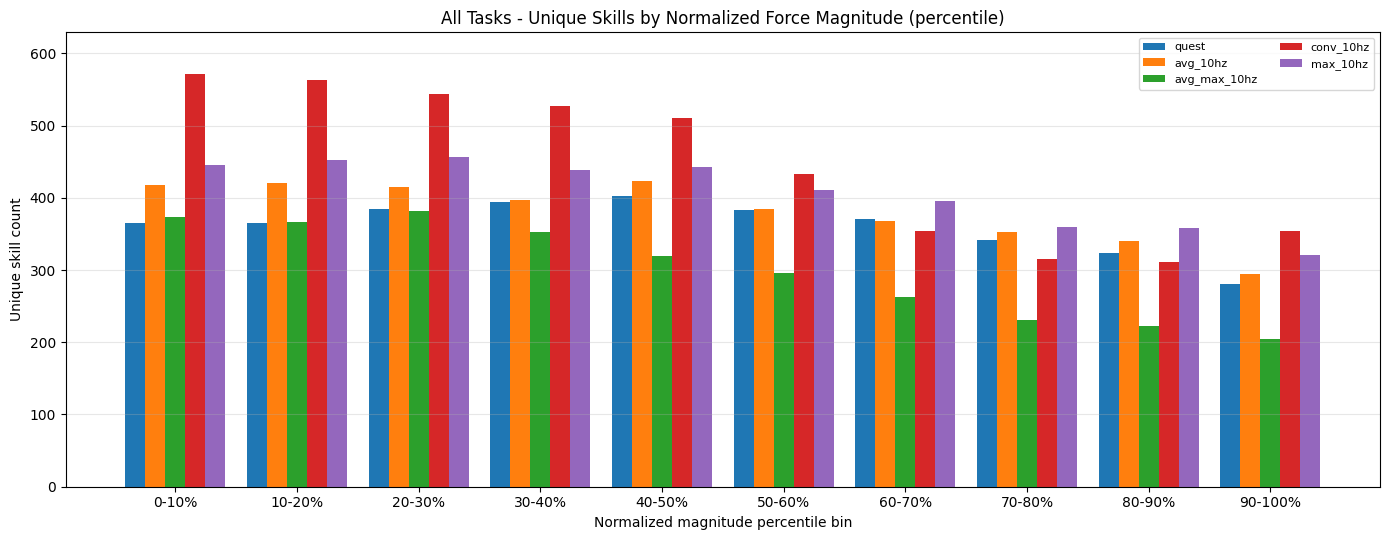

Saved figure: /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/all_tasks/all_tasks__torque__normalized_percentile_10bins.png


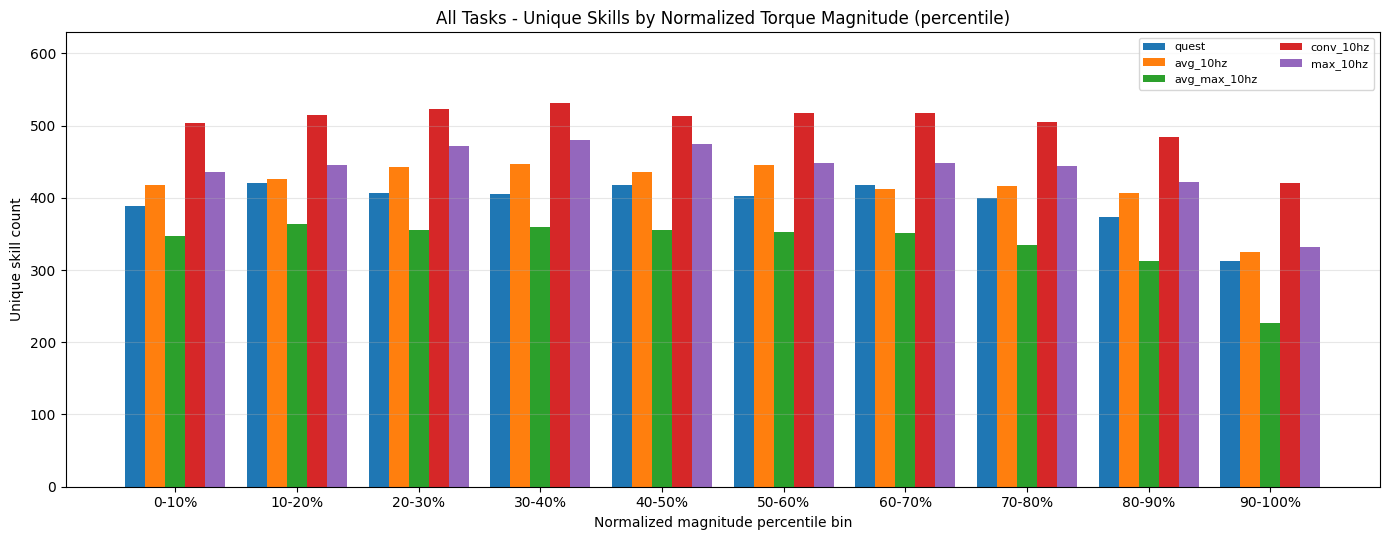

Saved all-task normalized comparison plots:
 - /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/all_tasks/all_tasks__force__normalized_percentile_10bins.png
 - /NHNHOME/WORKSPACE/0226010443_A/seunghyo/real_robot/QueST/visualize/output/all_tasks/all_tasks__torque__normalized_percentile_10bins.png


In [12]:
# All-task normalized comparison.
# Force/torque are normalized per task using force_torque_stats.json, then merged across all tasks.
ALL_TASK_BIN_MODE = "percentile"  # "value" or "percentile"
ALL_TASK_NUM_BINS = 10
ALL_TASK_OUTPUT_DIR = Path.cwd() / "output" / "all_tasks"

all_task_comparison_results = plot_all_tasks_normalized_force_torque_comparison(
    autoencoder_models=autoencoder_models,
    data_prefix=data_prefix,
    device=device,
    stats_path=FORCE_TORQUE_STATS_PATH,
    task_names=None,  # None means all tasks present in force_torque_stats.json and data_prefix.
    num_bins=ALL_TASK_NUM_BINS,
    bin_mode=ALL_TASK_BIN_MODE,
    output_dir=ALL_TASK_OUTPUT_DIR,
)

print("Saved all-task normalized comparison plots:")
print(" -", all_task_comparison_results["force"]["save_path"])
print(" -", all_task_comparison_results["torque"]["save_path"])
